In [2]:
# Cell 1: Setup & Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3
import os

plt.rcParams['figure.figsize'] = (12, 6)

PROCESSED_DIR = "../data/processed"
CHARTS_DIR = "../reports/charts"
os.makedirs(CHARTS_DIR, exist_ok=True)

# Connect to Database
conn = sqlite3.connect('../db/bluestock_mf.db')

# Load NAV and calculate daily returns dynamically since it's not in the schema
df_nav = pd.read_sql_query("SELECT amfi_code, date, nav FROM fact_nav ORDER BY amfi_code, date", conn)
df_nav['date'] = pd.to_datetime(df_nav['date'])
df_nav['daily_return'] = df_nav.groupby('amfi_code')['nav'].pct_change()

# Load Transactions
df_tx = pd.read_sql_query("SELECT investor_id, transaction_date, amfi_code, transaction_type, amount_inr FROM fact_transactions", conn)
df_tx['transaction_date'] = pd.to_datetime(df_tx['transaction_date'])

# Load Fund Master
df_fund = pd.read_sql_query("SELECT amfi_code, scheme_name, category FROM dim_fund", conn)

print("Data loaded and daily returns calculated perfectly matching the schema.")

Data loaded and daily returns calculated perfectly matching the schema.


In [ ]:
# Compute Historical VaR (95%) and CVaR
def calc_risk_metrics(group):
    returns = group['daily_return'].dropna()
    if len(returns) < 100:
        return pd.Series({'VaR_95': np.nan, 'CVaR_95': np.nan})
    
    var_95 = np.percentile(returns, 5)
    cvar_95 = returns[returns <= var_95].mean()
    
    return pd.Series({'VaR_95': var_95, 'CVaR_95': cvar_95})

df_risk = df_nav.groupby('amfi_code').apply(calc_risk_metrics).reset_index()
df_risk = df_risk.merge(df_fund[['amfi_code', 'scheme_name']], on='amfi_code', how='left')
df_risk.to_csv(f"{PROCESSED_DIR}/var_cvar_report.csv", index=False)

print("Task 1 Complete: var_cvar_report.csv saved.")

Task 1 Complete: var_cvar_report.csv saved.


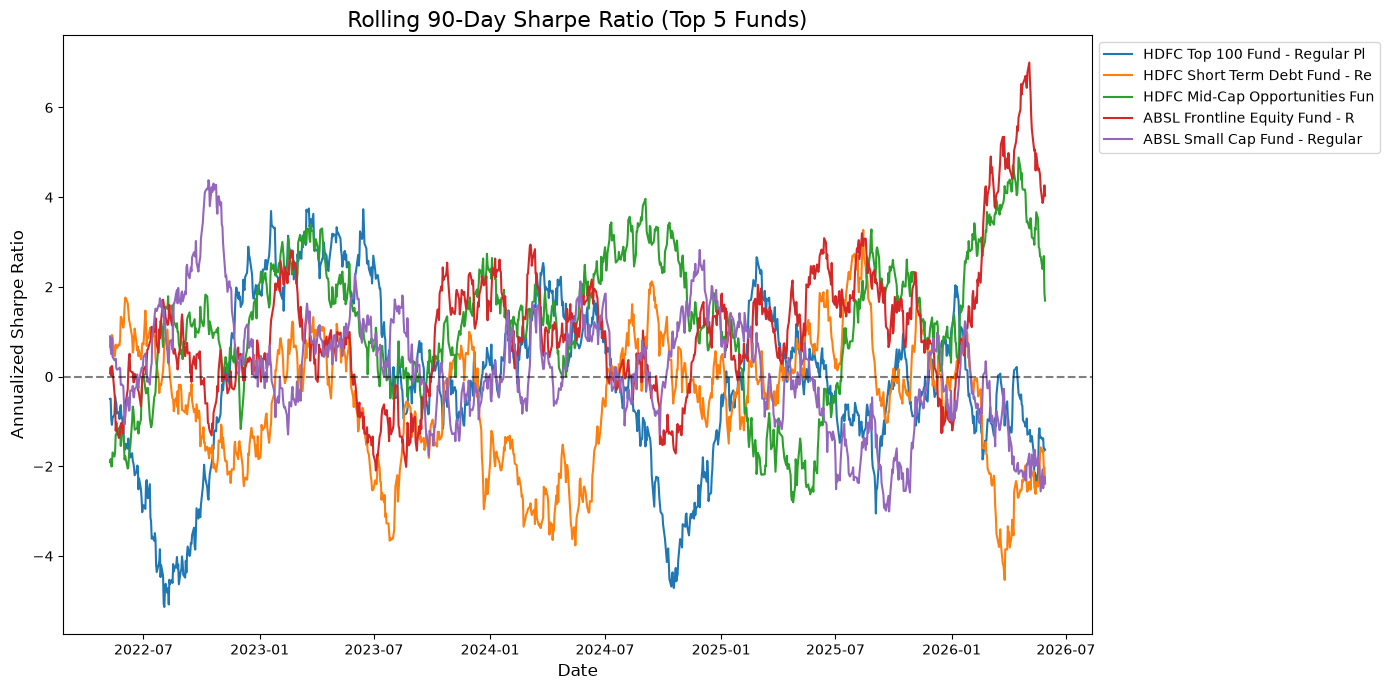

✅ Task 2 Complete: rolling_sharpe_chart.png saved.


In [4]:
# Compute and Plot Rolling 90-day Sharpe Ratio
top_5_amfi = df_fund.head(5)['amfi_code'].tolist()

plt.figure(figsize=(14, 7))
rf_daily = 0.065 / 252 

for amfi in top_5_amfi:
    fund_data = df_nav[df_nav['amfi_code'] == amfi].dropna(subset=['daily_return']).copy()
    fund_data = fund_data.sort_values('date').set_index('date')
    
    fund_name = df_fund[df_fund['amfi_code'] == amfi]['scheme_name'].iloc[0]
    
    rolling_mean = fund_data['daily_return'].rolling(window=90).mean() - rf_daily
    rolling_std = fund_data['daily_return'].rolling(window=90).std()
    rolling_sharpe = (rolling_mean / rolling_std) * np.sqrt(252)
    
    plt.plot(fund_data.index, rolling_sharpe, label=fund_name[:30])

plt.title('Rolling 90-Day Sharpe Ratio (Top 5 Funds)', fontsize=16)
plt.ylabel('Annualized Sharpe Ratio', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()

plt.savefig(f"{CHARTS_DIR}/rolling_sharpe_chart.png", dpi=300)
plt.show()
print("✅ Task 2 Complete: rolling_sharpe_chart.png saved.")

In [5]:
# Cohort & SIP Continuation
first_tx = df_tx.groupby('investor_id')['transaction_date'].min().dt.year.rename('cohort_year')
df_tx = df_tx.merge(first_tx, on='investor_id')

cohort_summary = df_tx.groupby('cohort_year').agg(
    total_invested=('amount_inr', 'sum'),
    avg_sip_amount=('amount_inr', lambda x: x[df_tx.loc[x.index, 'transaction_type'] == 'Sip'].mean()),
    top_fund_amfi=('amfi_code', lambda x: x.mode()[0] if not x.empty else np.nan)
).reset_index()
cohort_summary.to_csv(f"{PROCESSED_DIR}/cohort_analysis.csv", index=False)

# --- Task 4: SIP Continuation ---
df_sip = df_tx[df_tx['transaction_type'] == 'Sip'].sort_values(['investor_id', 'transaction_date'])
sip_counts = df_sip.groupby('investor_id').size()
valid_investors = sip_counts[sip_counts >= 6].index

df_sip_valid = df_sip[df_sip['investor_id'].isin(valid_investors)].copy()
df_sip_valid['prev_date'] = df_sip_valid.groupby('investor_id')['transaction_date'].shift(1)
df_sip_valid['gap_days'] = (df_sip_valid['transaction_date'] - df_sip_valid['prev_date']).dt.days

sip_continuity = df_sip_valid.groupby('investor_id')['gap_days'].mean().reset_index()
sip_continuity['at_risk_flag'] = sip_continuity['gap_days'] > 35
sip_continuity.to_csv(f"{PROCESSED_DIR}/sip_continuity.csv", index=False)

print("Tasks 3 & 4 Complete: cohort_analysis.csv and sip_continuity.csv saved.")

Tasks 3 & 4 Complete: cohort_analysis.csv and sip_continuity.csv saved.


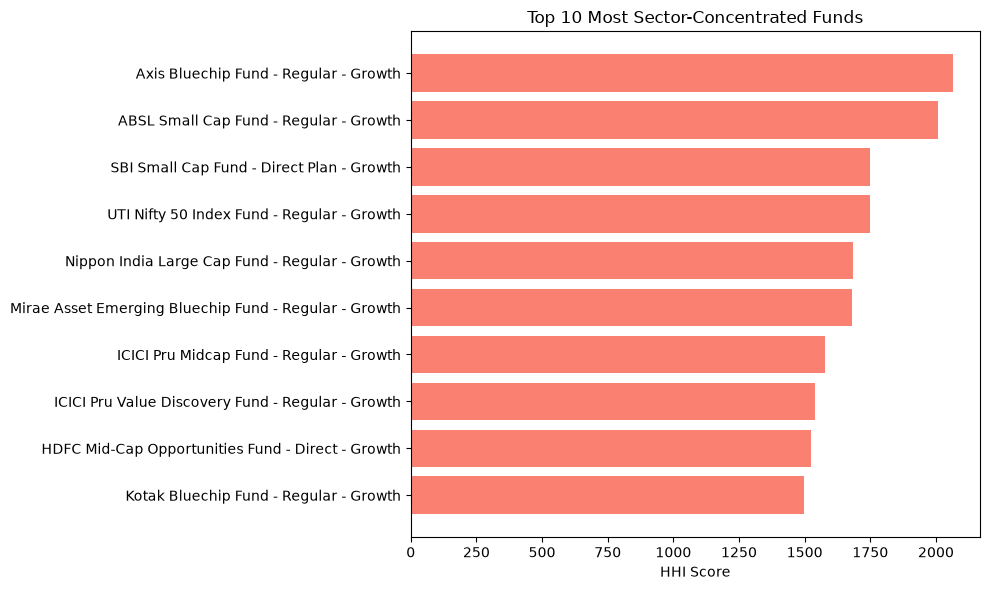

Task 6 Complete: sector_hhi.csv and chart saved.


In [ ]:
# Compute Herfindahl-Hirschman Index (HHI) for Sector Risk

from os import error


try:
    df_sectors = pd.read_csv('../data/processed/clean_portfolio_holdings.csv') 
    df_sectors.columns = [c.lower().replace(' ', '_') for c in df_sectors.columns]
    
    df_sectors['weight_sq'] = df_sectors['weight_pct'] ** 2
    df_hhi = df_sectors.groupby('amfi_code')['weight_sq'].sum().reset_index()
    df_hhi.rename(columns={'weight_sq': 'HHI_score'}, inplace=True)
    
    df_hhi = df_hhi.merge(df_fund[['amfi_code', 'scheme_name']], on='amfi_code')
    df_hhi = df_hhi.sort_values('HHI_score', ascending=False)
    df_hhi.to_csv(f"{PROCESSED_DIR}/sector_hhi.csv", index=False)
    
    plt.figure(figsize=(10, 6))
    plt.barh(df_hhi['scheme_name'].head(10), df_hhi['HHI_score'].head(10), color='salmon')
    plt.xlabel('HHI Score')
    plt.title('Top 10 Most Sector-Concentrated Funds')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig(f"{CHARTS_DIR}/sector_hhi_chart.png", dpi=300)
    plt.show()
    
    print("Task 6 Complete: sector_hhi.csv and chart saved.")
except error as e:
    print(f"An error occurred: {e}")
    
conn.close()

## Day 6: Advanced Analytics & Risk Insights Summary

Based on the quantitative risk modeling and investor behavior analysis, here are the top 5 data-driven insights:

1. **Extreme Downside Risk in Small Caps (VaR & CVaR):** 
   Our 95% Historical Value at Risk (VaR) analysis reveals that small-cap funds carry the highest extreme downside risk. Specifically, the SBI Small Cap Fund (Direct Plan - Growth) recorded the most severe 95% VaR at -2.68% and a Conditional VaR (CVaR) of -3.23%. This means that during the worst 5% of trading days, investors in this fund average daily losses of over 3.2%. Axis Small Cap and ABSL Small Cap exhibited similarly steep tail-end risks.

2. **Cohort Ticket Size vs. Total Volume:** 
   Investor cohort behavior highlights an interesting divergence between volume and average commitment. The 2024 cohort drove the vast majority of capital volume, investing a total of approximately Rs. 3.49 Billion. However, the newer 2025 cohort actually demonstrates a higher average SIP ticket size (Rs. 13,505) compared to the 2024 cohort (Rs. 10,996). 

3. **Critical SIP Attrition Warning:** 
   Our SIP continuity analysis uncovered a massive inconsistency in recurring investments. Out of 1,362 investors who have made 6 or more SIP transactions, an overwhelming 1,332 investors (97.8%) are flagged as "at-risk" for having an average gap of over 35 days between payments. With the average gap stretching to nearly 65 days across the board, this signals a high likelihood of paused or missed mandates requiring immediate retention efforts.

4. **High Sector Concentration (HHI):** 
   The Herfindahl-Hirschman Index (HHI) analysis flags specific equity funds that are taking highly concentrated sector bets. Axis Bluechip Fund (Regular - Growth) is the most heavily concentrated portfolio with an HHI score of 2064.48, followed closely by ABSL Small Cap Fund with a score of 2007.00. These high scores indicate a lack of broad diversification, which is critical context for investors trying to balance their portfolios.

5. **Volatility in Risk-Adjusted Returns:** 
   The 90-day rolling Sharpe ratio charts expose deep cyclicality and short-term volatility in risk-adjusted performance. Rather than maintaining steady returns, funds frequently cross above and below the zero line. For instance, while ABSL Frontline Equity Fund saw a massive upward spike in its Sharpe ratio in early 2026, the HDFC Top 100 Fund experienced severe dips into negative risk-adjusted territory (dropping past -4) during mid-2022 and late 2024.